In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.io import fits

In [2]:
#file_amt_high = "../data/iprt_amt_l1_high_08bit_20260429-0853_v02_00.fits"
#file_amt_high = "../data/iprt_amt_l1_high_16bit_20260429-0853_v02_00.fits"
#file_amt_high = "../data/iprt_amt_l1_high_16bit_20260601-0600_v02_00.fits"
file_amt_high = "../data/iprt_amt_l1_high_16bit_20260705-0300_v02_00.fits"

with fits.open(file_amt_high) as hdul:
    amt_hdr = hdul[0].header
    amt_data = hdul[0].data

high_r, high_l  = amt_data

In [3]:
date_obs = amt_hdr['DATE-OBS']
time_obs =amt_hdr['TIME-OBS']
exptime = amt_hdr['EXPTIME']
naxis1 = amt_hdr['NAXIS1']

start_dt = np.datetime64(f"{date_obs}T{time_obs}")
step_us = int(exptime * 1e6) 
tm = start_dt + np.arange(naxis1) * np.timedelta64(step_us, 'us')

freq_min = amt_hdr['CRVAL2']
df =amt_hdr['CDELT2']
naxis2 = amt_hdr['NAXIS2']
freq = freq_min + np.arange(naxis2) * df

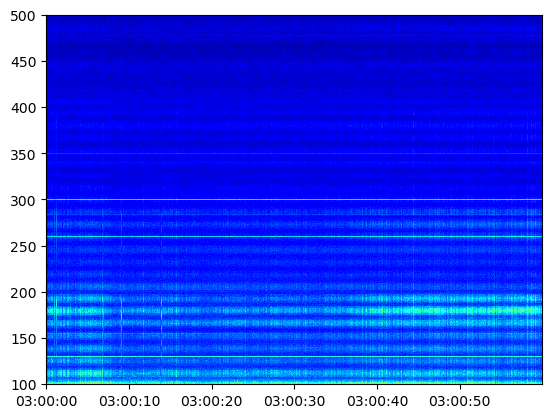

In [4]:
fig = plt.figure()
im = plt.pcolormesh(tm, freq, high_r, cmap='jet')


In [6]:
file_amt_low = "../data/iprt_amt_l1_low_08bit_20260705_v02_00.fits"

with fits.open(file_amt_low) as hdul:
    amt_hdr_low = hdul[0].header
    amt_data_low = hdul[0].data

low_r, low_l  = amt_data_low

In [7]:
date_obs = amt_hdr_low['DATE-OBS']
time_obs =amt_hdr_low['TIME-OBS']
exptime = amt_hdr_low['EXPTIME']
naxis1 = amt_hdr_low['NAXIS1']

start_dt = np.datetime64(f"{date_obs}T{time_obs}")
step_us = int(exptime * 1e6) 
tm = start_dt + np.arange(naxis1) * np.timedelta64(step_us, 'us')

freq_min = amt_hdr_low['CRVAL2']
df =amt_hdr_low['CDELT2']
naxis2 = amt_hdr_low['NAXIS2']
freq_low = freq_min + np.arange(naxis2) * df

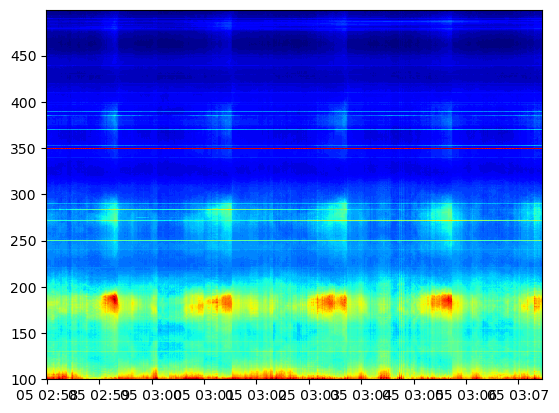

In [8]:
fig = plt.figure()
im = plt.pcolormesh(tm, freq_low, low_r, cmap='jet')